In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import random

##### 회전

In [6]:


# 이미지를 다양한 각도로 회전시켜 저장
# Parameters:
# - image_path: 이미지 파일 경로
# - angle_unit: 회전 각도 단위 (예: 15도)
# - count: 생성할 이미지 개수
# - output_dir: 저장할 폴더 경로
# Returns: 저장된 파일 경로 리스트
def rotate_images(image_path, angle_unit, count, output_dir) -> list[str]:
    # 저장 폴더 생성
    os.makedirs(output_dir, exist_ok=True)
    
    # 이미지 불러오기
    image = cv2.imread(image_path)
    
    # 이미지의 높이와 너비 추출
    h, w = image.shape[:2]
    
    # 중심점 계산
    center = (w // 2, h // 2)
    
    # 원본 이미지의 배경색 추출 (모서리 네 곳의 평균)
    # - image[0, 0] = [B, G, R] 형식으로 색상 정보가 저장되어 있음
    # - ndarray([[B, G, R], 
    #            [B, G, R], 
    #            [B, G, R], 
    #            [B, G, R]]) -> 0축 방향 평균 계산
    # - ndarray([avg_B, avg_G, avg_R]) -> 정수형 변환 -> 리스트 변환
    # - [avg_R, avg_G, avg_B]
    bg_color = np.mean([
        image[0, 0],      # 좌상단
        image[0, w-1],    # 우상단
        image[h-1, 0],    # 좌하단
        image[h-1, w-1]   # 우하단
    ], axis=0).astype(int).tolist()
    
    # 회전된 이미지 저장
    saved_files = []
    for i in range(count):
        # 회전 각도 계산
        angle = (angle_unit * (i // 2 + 1) 
                 if i % 2 == 0 
                 else -angle_unit * (i // 2 + 1))
        
        # 회전 행렬 계산
        M = cv2.getRotationMatrix2D(center, angle, 1.0)

        # 회전 적용 (배경을 원본 이미지의 배경색과 동일하게 설정)
        # warpAffine(): 워프아핀
        # - 이미지를 회전, 이동, 스케일링 등으로 변환하는 함수
        rotated = cv2.warpAffine(
            image, M, (w, h), borderValue=bg_color)
        
        # 파일로 저장
        output_filename = os.path.join(output_dir, 
                                       f"rotated_{angle:+03d}.jpg")
        cv2.imwrite(output_filename, rotated)
        saved_files.append(output_filename)
    
    print(f"이미지 {count}개가 '{output_dir}' 폴더에 저장")
    return saved_files

In [7]:
# 함수 호출
saved_files = rotate_images("../images/cup.jpg", 
                            angle_unit=15, 
                            count=4, 
                            output_dir="output")

이미지 4개가 'output' 폴더에 저장


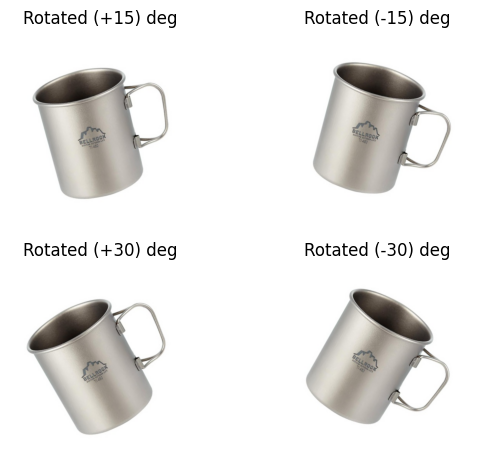

In [8]:
# 저장된 이미지 중 4개 시각화
fig, axes = plt.subplots(2, 2)
for idx, filepath in enumerate(saved_files, 1):
    image = cv2.imread(filepath)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    # 파일명에서 각도 추출
    filename = os.path.basename(filepath)
    angle = filename.replace("rotated_", "").replace(".jpg", "")
    
    ax = axes[(idx-1)//2, (idx-1)%2]
    ax.imshow(image_rgb)
    ax.set_title(f"Rotated ({angle}) deg")
    ax.axis('off')

fig.tight_layout()
plt.show()

##### 이동

In [9]:
# 이미지를 다양한 방향으로 이동시켜 저장
# Parameters:
# - image_path: 이미지 파일 경로
# - shift_unit: 이동 거리 단위 (예: 50픽셀)
# - output_dir: 저장할 폴더 경로
# Returns: 저장된 파일 정보 리스트 (경로, 방향, 거리)
def translate_images(image_path, shift_unit, output_dir):
    # 저장 폴더 생성
    os.makedirs(output_dir, exist_ok=True)
    
    # 이미지 불러오기
    image = cv2.imread(image_path)
    
    # 이미지의 높이와 너비 추출
    h, w = image.shape[:2]
    
    # 이동 방향 설정 (오른쪽, 왼쪽, 아래, 위)
    translations = [
        (shift_unit, 0, "Right"),      # 오른쪽
        (-shift_unit, 0, "Left"),      # 왼쪽
        (0, shift_unit, "Down"),       # 아래
        (0, -shift_unit, "Up")         # 위
    ]
    
    # 원본 이미지의 배경색 추출 (모서리 네 곳의 평균)
    bg_color = np.mean([
        image[0, 0],      # 좌상단
        image[0, w-1],    # 우상단
        image[h-1, 0],    # 좌하단
        image[h-1, w-1]   # 우하단
    ], axis=0).astype(int).tolist()
    
    saved_files = []
    for tx, ty, direction in translations:
        # 이동 행렬 생성
        M = np.float32([
            [1, 0, tx],
            [0, 1, ty]
        ])
        
        # 이동 적용 (배경을 원본 이미지의 배경색과 동일하게 설정)
        translated = cv2.warpAffine(image, M, (w, h), 
                                    borderValue=bg_color)
        
        # 파일로 저장
        output_filename = os.path.join(
            output_dir, f"translated_{direction.lower()}.jpg")
        cv2.imwrite(output_filename, translated)
        saved_files.append((output_filename, direction, 
                            abs(tx) if tx != 0 else abs(ty)))
    
    print(f"이미지 {len(translations)}개가 '{output_dir}' 폴더에 저장")
    return saved_files

In [10]:
# 함수 호출
saved_files = translate_images("../images/cup.jpg", 
                               shift_unit=50, 
                               output_dir="output")

이미지 4개가 'output' 폴더에 저장


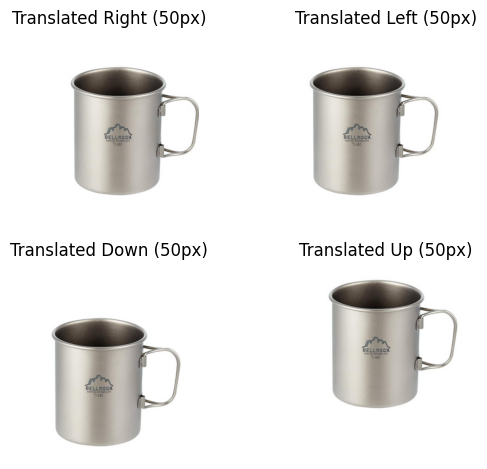

In [11]:

# 저장된 이미지 전체 시각화 (4개)
fig, axes = plt.subplots(2, 2)
for idx, (filepath, direction, distance) in enumerate(saved_files, 1):
    image = cv2.imread(filepath)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    ax = axes[(idx-1)//2, (idx-1)%2]
    ax.imshow(image_rgb)
    ax.set_title(f"Translated {direction} ({distance}px)")
    ax.axis('off')

fig.tight_layout()
plt.show()


##### 뒤집기

In [12]:
# 이미지를 좌우/상하 반전시켜 저장
# Parameters:
# - image_path: 이미지 파일 경로
# - output_dir: 저장할 폴더 경로
# Returns: 저장된 파일 정보 리스트 (경로, 반전 방향)
def flip_images(image_path, output_dir):
    # 저장 폴더 생성
    os.makedirs(output_dir, exist_ok=True)
    
    # 이미지 불러오기
    image = cv2.imread(image_path)
    
    # 좌우 반전
    flip_horizontal = cv2.flip(image, 1)
    
    # 상하 반전
    flip_vertical = cv2.flip(image, 0)
    
    # 반전 이미지 정보
    flips = [
        (flip_horizontal, "Horizontal"),
        (flip_vertical, "Vertical")
    ]
    
    saved_files = []
    for flipped_image, direction in flips:
        # 파일로 저장
        output_filename = os.path.join(
            output_dir, f"flipped_{direction.lower()}.jpg")
        cv2.imwrite(output_filename, flipped_image)
        saved_files.append((output_filename, direction))
    
    print(f"이미지 {len(flips)}개가 '{output_dir}' 폴더에 저장")
    return saved_files

In [13]:
# 함수 호출
saved_files = flip_images("../images/cup.jpg", output_dir="output")

이미지 2개가 'output' 폴더에 저장


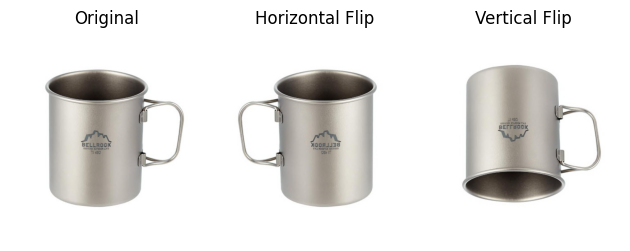

In [14]:
# 저장된 이미지 시각화
fig, axes = plt.subplots(1, 3)

# 원본 이미지
original = cv2.imread("../images/cup.jpg")
axes[0].imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
axes[0].set_title("Original")
axes[0].axis('off')

# 반전된 이미지들
(filepath0, direction0), (filepath1, direction1) = saved_files
axes[1].imshow(cv2.cvtColor(cv2.imread(filepath0), cv2.COLOR_BGR2RGB))
axes[1].set_title(f"{direction0} Flip")
axes[1].axis('off')
axes[2].imshow(cv2.cvtColor(cv2.imread(filepath1), cv2.COLOR_BGR2RGB))
axes[2].set_title(f"{direction1} Flip")
axes[2].axis('off')

fig.tight_layout()
plt.show()


##### 밝기

In [15]:
# 이미지의 밝기를 다양하게 조정하여 저장
# Parameters:
# - image_path: 이미지 파일 경로
# - brightness_values: 밝기 조정 값 리스트 (예: [-40, 40])
# - output_dir: 저장할 폴더 경로
# Returns: 저장된 파일 정보 리스트 (경로, 밝기 값)
def adjust_brightness(image_path, brightness_values, output_dir):
    # 저장 폴더 생성
    os.makedirs(output_dir, exist_ok=True)
    
    # 이미지 불러오기
    image = cv2.imread(image_path)
    
    saved_files = []
    for beta in brightness_values:
        # 밝기 조정 (beta: 밝기 증감 값)
        adjusted = cv2.convertScaleAbs(image, alpha=1.0, beta=beta)
        
        # 파일로 저장
        output_filename = os.path.join(
            output_dir, f"brightness_{beta:+03d}.jpg")
        cv2.imwrite(output_filename, adjusted)
        saved_files.append((output_filename, beta))
    
    print(f"이미지 {len(brightness_values)}개가 '{output_dir}' 폴더에 저장")
    return saved_files

In [16]:
# 함수 호출
saved_files = adjust_brightness("../images/cup.jpg", 
                                brightness_values=[-40, 40], 
                                output_dir="output")

이미지 2개가 'output' 폴더에 저장


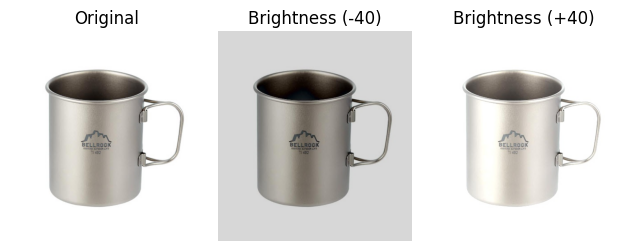

In [17]:

# 저장된 이미지 시각화
fig, axes = plt.subplots(1, 3)

# 원본 이미지
original = cv2.imread("../images/cup.jpg")
axes[0].imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
axes[0].set_title("Original")
axes[0].axis('off')

# 밝기 조정된 이미지들
(filepath0, beta0), (filepath1, beta1) = saved_files
axes[1].imshow(cv2.cvtColor(cv2.imread(filepath0), cv2.COLOR_BGR2RGB))
axes[1].set_title(f"Brightness ({beta0:+d})")
axes[1].axis('off')
axes[2].imshow(cv2.cvtColor(cv2.imread(filepath1), cv2.COLOR_BGR2RGB))
axes[2].set_title(f"Brightness ({beta1:+d})")
axes[2].axis('off')

fig.tight_layout()
plt.show()


##### 랜덤 증강

In [18]:
# 이미지에 랜덤한 증강을 적용하는 함수
def random_augment(image):
    # 이미지의 높이와 너비 추출
    h, w = image.shape[:2]
    
    # 원본 이미지의 배경색 추출 (모서리 네 곳의 평균)
    bg_color = np.mean([
        image[0, 0],      # 좌상단
        image[0, w-1],    # 우상단
        image[h-1, 0],    # 좌하단
        image[h-1, w-1]   # 우하단
    ], axis=0).astype(int).tolist()    

    # 랜덤 회전
    angle = random.uniform(-15, 15) # -15도에서 15도 사이의 랜덤 각도
    M = cv2.getRotationMatrix2D((w//2, h//2), angle, 1.0)
    image = cv2.warpAffine(image, M, (w, h), borderValue=bg_color)

    # 랜덤 이동
    tx = random.randint(-20, 20)
    ty = random.randint(-20, 20)
    M = np.float32([[1, 0, tx], [0, 1, ty]])
    image = cv2.warpAffine(image, M, (w, h), borderValue=bg_color)

    # 랜덤 밝기
    beta = random.randint(-40, 40)
    image = cv2.convertScaleAbs(image, alpha=1.0, beta=beta)

    # 50% 확률로 뒤집기
    if random.random() > 0.5:
        image = cv2.flip(image, 1)

    return image

In [19]:


# 이미지에 랜덤 증강을 적용하여 여러 개 생성 및 저장
# Parameters:
# - image_path: 이미지 파일 경로
# - count: 생성할 이미지 개수
# - output_dir: 저장할 폴더 경로
# Returns: 저장된 파일 경로 리스트
def generate_random_augmented_images(image_path, count, output_dir):
    # 저장 폴더 생성
    os.makedirs(output_dir, exist_ok=True)
    
    # 이미지 불러오기
    image = cv2.imread(image_path)
    
    saved_files = []
    for i in range(count):
        # 랜덤 증강 적용
        augmented = random_augment(image.copy())
        
        # 파일로 저장
        output_filename = os.path.join(
            output_dir, f"random_aug_{i+1:02d}.jpg")
        cv2.imwrite(output_filename, augmented)
        saved_files.append(output_filename)
    
    print(f"이미지 {count}개가 '{output_dir}' 폴더에 저장")
    return saved_files

In [20]:

# 함수 호출
saved_files = generate_random_augmented_images(
    "../images/cup.jpg", count=20, output_dir="output")

이미지 20개가 'output' 폴더에 저장


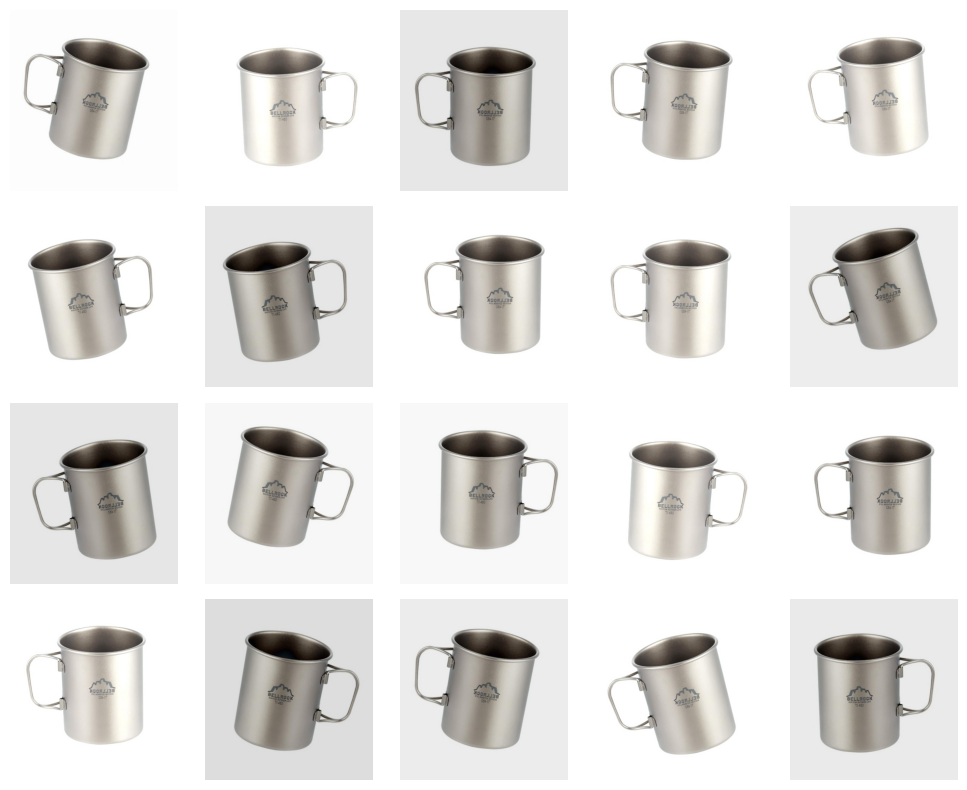

In [21]:
# 저장된 이미지 시각화
fig, axes = plt.subplots(4, 5, figsize=(5*2, 4*2))

for ax, filepath in zip(axes.flatten(), saved_files):
    image = cv2.imread(filepath)
    ax.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    ax.axis('off')

fig.tight_layout()
plt.show()
